Epoch: 392  |  Loss: 0.670310  |  c: 0.002873  |  LR: 5.11e-03
Epoch: 393  |  Loss: 0.679955  |  c: 0.002915  |  LR: 5.10e-03
Epoch: 394  |  Loss: 0.670194  |  c: 0.002873  |  LR: 5.09e-03
Epoch: 395  |  Loss: 0.671367  |  c: 0.002878  |  LR: 5.07e-03
Epoch: 396  |  Loss: 0.669954  |  c: 0.002872  |  LR: 5.06e-03
Epoch: 397  |  Loss: 0.670327  |  c: 0.002873  |  LR: 5.05e-03
Epoch: 398  |  Loss: 0.669771  |  c: 0.002871  |  LR: 5.04e-03
Epoch: 399  |  Loss: 0.669860  |  c: 0.002872  |  LR: 5.02e-03
Epoch: 400  |  Loss: 0.669589  |  c: 0.002870  |  LR: 5.01e-03
Total training time: 190.6s


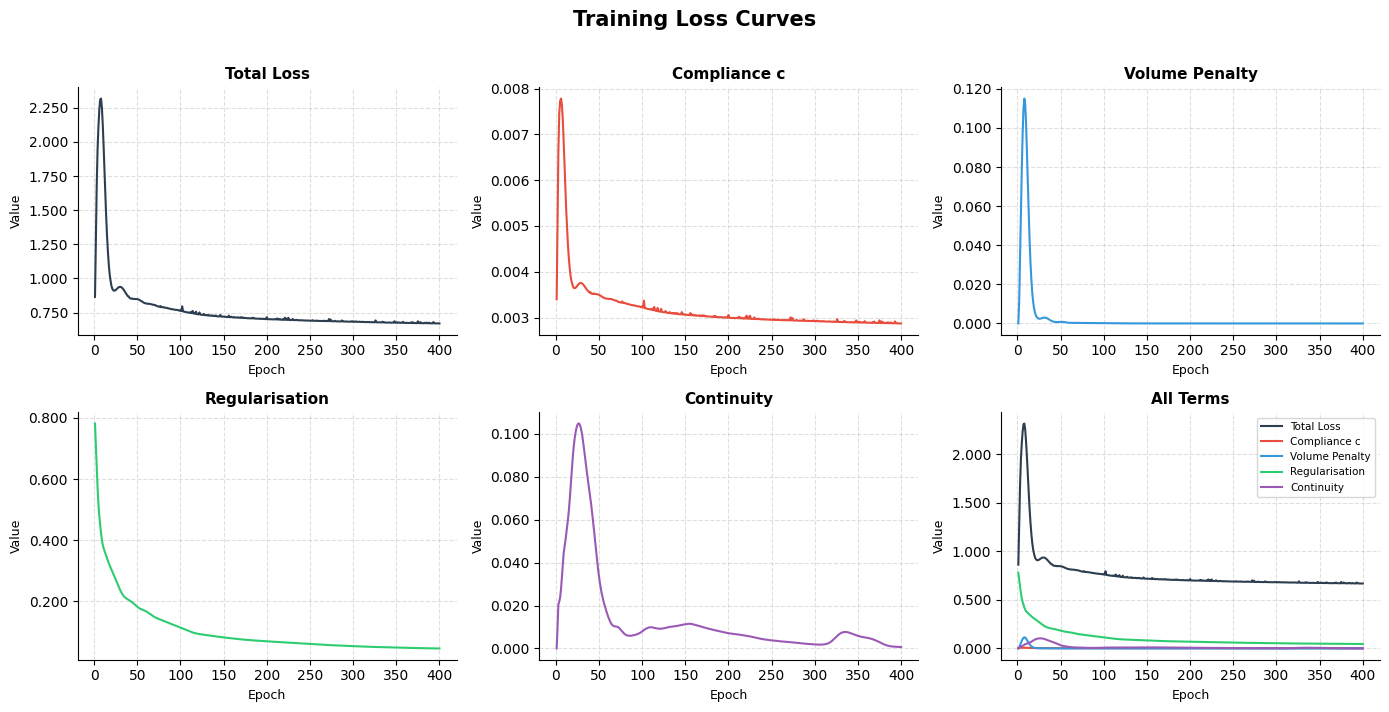

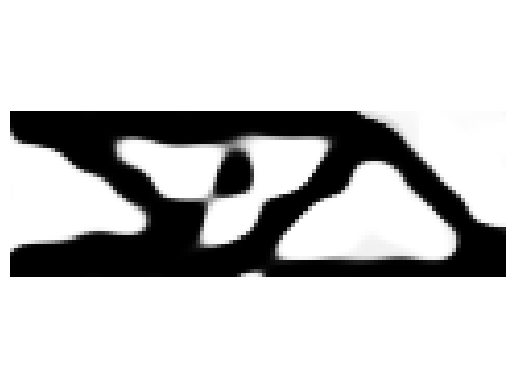

In [1]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
from IPython import display
from scipy.sparse import coo_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
import time

device = 'cuda:2'


# ══════════════════════════════════════════════════════════════════════════════
#  Problem definitions  (unchanged)
# ══════════════════════════════════════════════════════════════════════════════

class Problems():
    def dlX_disp(self):
        domain_xcoord = np.random.uniform(
            -self.nelx / (2 * self.nelm),
             self.nelx / (2 * self.nelm),
            (self.batch_size - self.dlX_fixed.shape[0] - self.dlX_force.shape[0], 1)
        )
        domain_ycoord = np.random.uniform(
            -self.nely / (2 * self.nelm),
             self.nely / (2 * self.nelm),
            (self.batch_size - self.dlX_fixed.shape[0] - self.dlX_force.shape[0], 1)
        )
        domain_coord = np.concatenate((domain_ycoord, domain_xcoord), axis=1)
        coord = np.concatenate(
            (self.dlX_fixed.cpu().detach().numpy(),
             self.dlX_force.cpu().detach().numpy()),
            axis=0
        )
        coord = np.concatenate((coord, domain_coord), axis=0)
        coord = torch.tensor(coord, dtype=torch.float32, requires_grad=True).to(device)
        return coord


class Cantilever_Beam_2D(Problems):
    def __init__(self, nelx, nely, xid, yid, vf):

        # Initialize geometry parameters
        
        self.xid  = xid
        self.yid  = yid
        self.nelx = nelx
        self.nely = nely

        self.nele     = self.nelx * self.nely
        self.nelm     = max(self.nelx, self.nely)
        self.volfrac  = vf
        self.E0       = 1
        self.nu       = 0.3

        self.batch_size   = 25000
        self.alpha_init   = 1
        self.alpha_max    = 100
        self.alpha_delta  = 0.5
        self.penal        = 3.0

        c_y, c_x = np.meshgrid(
            np.linspace(-(self.nely) / (2 * self.nelm),  (self.nely) / (2 * self.nelm),  self.nely),
            np.linspace(-(self.nelx) / (2 * self.nelm),  (self.nelx) / (2 * self.nelm),  self.nelx),
            indexing='ij'
        )
        self.dlX = np.stack((c_y.reshape([-1]), c_x.reshape([-1])), axis=1).reshape([-1, 2])

        c_y, c_x = np.meshgrid(
            np.linspace(-(self.nely) / (2 * self.nelm),  (self.nely) / (2 * self.nelm),  2 * self.nely),
            np.linspace(-(self.nelx) / (2 * self.nelm),  (self.nelx) / (2 * self.nelm),  2 * self.nelx),
            indexing='ij'
        )
        self.dlXSS = np.stack((c_y.reshape([-1]), c_x.reshape([-1])), axis=1).reshape([-1, 2])
        self.V = (
            (np.max(self.dlX[:, 0]) - np.min(self.dlX[:, 0])) *
            (np.max(self.dlX[:, 1]) - np.min(self.dlX[:, 1]))
        )

        # Boundary conditions
        fixed_voxel         = np.zeros((self.nely, self.nelx))
        fixed_voxel[:, 0]   = 1.0
        fixed_voxel         = fixed_voxel.reshape([self.nele, 1])
        dlX_fixed           = self.dlX[np.where(fixed_voxel == 1.0)[0], :]

        F = 0.1
        self.F_vector   = torch.tensor([[F], [0.0]], dtype=torch.float32).to(device)
        self.force_voxel           = np.zeros((self.nely, self.nelx))
        self.force_voxel[yid, xid] = 1
        force_voxel = self.force_voxel.reshape([self.nele, 1])
        dlX_force   = self.dlX[np.where(force_voxel == 1)[0], :]

        self.dlX      = torch.tensor(self.dlX,      dtype=torch.float32, requires_grad=True).to(device)
        self.dlXSS    = torch.tensor(self.dlXSS,    dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_fixed = torch.tensor(dlX_fixed,    dtype=torch.float32, requires_grad=True).to(device)
        self.dlX_force = torch.tensor(dlX_force,    dtype=torch.float32, requires_grad=True).to(device)

    def analytical_fixed_BC(self, u, coord):
        u = u * 2 * (1 / (1 + torch.exp(-20 * (coord[:, 1:2] + 0.5))) - 0.5)
        return u
    
_BAND_LOW, _BAND_HIGH = 0.0, 10.0


def _build_spectral_kernel(n_basis: int = 100,
                           band_low:  float = _BAND_LOW,
                           band_high: float = _BAND_HIGH,
                           seed: int = None) -> torch.Tensor:
    """
    在 [-band_high, -band_low] ∪ [band_low, band_high] 范围内
    随机采样 n_basis 个 2D 频率向量。

    原来：n_y * n_x 个规则网格点（linspace + meshgrid）
    现在：n_basis 个随机点，数量可以任意指定，不受维度整除限制

    返回: [2, n_basis]  (与原接口完全兼容)
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    def _sample_1d(n):
        """在 [-band_high, -band_low] ∪ [band_low, band_high] 均匀采样 n 个值"""
        # 先在 [0, 1) 均匀采样，再映射到两段区间
        u = rng.uniform(0.0, 1.0, n)
        half = band_high - band_low          # 每段区间长度
        val  = u * 2 * half                  # [0, 2*half)
        # 前一半映射到 [-band_high, -band_low]，后一半映射到 [band_low, band_high]
        out        = np.where(val < half,
                              val - band_high,        # [-band_high, -band_low)
                              val - half + band_low)  # [band_low,    band_high)
        return out

    ky = _sample_1d(n_basis)   # [n_basis]
    kx = _sample_1d(n_basis)   # [n_basis]

    return torch.tensor(
        np.stack((ky, kx), axis=0),   # [2, n_basis]
        dtype=torch.float32,
    )


class _SpectralBase(nn.Module):
    def __init__(self, trainable_kernel: bool,
                 n_basis: int = 100,
                 band_low:  float = _BAND_LOW,
                 band_high: float = _BAND_HIGH,
                 seed: int = None):
        super().__init__()
        K = _build_spectral_kernel(n_basis, band_low, band_high, seed).to(device)
        if trainable_kernel:
            self.kernel1 = nn.Parameter(K)
        else:
            self.register_buffer('kernel1', K)
        self.register_buffer(
            '_bias', torch.ones(1, K.shape[1], dtype=torch.float32).to(device)
        )

    def _features(self, x: torch.Tensor) -> torch.Tensor:
        return torch.sin(x @ self.kernel1 + self._bias)   # [N, n_basis]


class Disp_Net(_SpectralBase):
    def __init__(self, n_basis: int = 400,
                 band_low:  float = _BAND_LOW,
                 band_high: float = _BAND_HIGH,
                 seed: int = 42):
        super().__init__(trainable_kernel=False,
                         n_basis=n_basis,
                         band_low=band_low, band_high=band_high, seed=seed)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self._features(x)



class TO_BlockNet(nn.Module):
    def __init__(self, n_cols: int = 2, n_rows: int = 2,
                 n_basis: int = 50,           # ← 每个 block 的基函数数量
                 band_low:  float = _BAND_LOW,
                 band_high: float = _BAND_HIGH,
                 overlap:   float = 0.0,
                 seed: int = None,
                 device: str = 'cuda:2'):
        super().__init__()
        self.n_cols   = int(n_cols)
        self.n_rows   = int(n_rows)
        self.n_blocks = self.n_cols * self.n_rows
        self.overlap  = overlap
        self.device   = device

        K = _build_spectral_kernel(n_basis, band_low, band_high, seed).to(device)
        self.M = K.shape[1]   # = n_basis
        self.kernels = nn.Parameter(
            K.unsqueeze(0).expand(self.n_blocks, -1, -1).clone()
        )
        self.weights = nn.Parameter(
            torch.zeros(self.n_blocks, self.M, device=device)
        )

    # ── 以下方法与原版完全相同，无需改动 ─────────────────────────────────────
    def _block_indices(self, coords):
        ys, xs = coords[:, 0], coords[:, 1]
        min_y, max_y = ys.min(), ys.max()
        min_x, max_x = xs.min(), xs.max()
        col = ((xs - min_x) / (max_x - min_x + 1e-9) * self.n_cols).long().clamp(0, self.n_cols - 1)
        row = ((ys - min_y) / (max_y - min_y + 1e-9) * self.n_rows).long().clamp(0, self.n_rows - 1)
        return row * self.n_cols + col

    def _soft_weights(self, coords):
        ys, xs = coords[:, 0:1], coords[:, 1:2]
        min_y, max_y = ys.min().item(), ys.max().item()
        min_x, max_x = xs.min().item(), xs.max().item()
        bh = (max_y - min_y) / self.n_rows
        bw = (max_x - min_x) / self.n_cols
        centers_y = torch.tensor(
            [min_y + (r + 0.5) * bh for r in range(self.n_rows) for c in range(self.n_cols)],
            dtype=torch.float32, device=self.device)
        centers_x = torch.tensor(
            [min_x + (c + 0.5) * bw for r in range(self.n_rows) for c in range(self.n_cols)],
            dtype=torch.float32, device=self.device)
        dy = (ys - centers_y.unsqueeze(0)) / (bh * (0.5 + self.overlap))
        dx = (xs - centers_x.unsqueeze(0)) / (bw * (0.5 + self.overlap))
        return torch.softmax(-0.5 * (dy ** 2 + dx ** 2), dim=1)

    def _all_blocks(self, coords):
        N, B, M = coords.shape[0], self.n_blocks, self.M
        K_flat = self.kernels.permute(1, 0, 2).reshape(2, B * M)
        z   = (coords @ K_flat).view(N, B, M) + 1.0
        out = (torch.sin(z) * self.weights.unsqueeze(0)).sum(dim=2)
        return torch.sigmoid(out)

    def forward(self, coords):
        coords  = coords.to(self.device)
        out_all = self._all_blocks(coords)
        if self.overlap <= 0:
            bidx = self._block_indices(coords)
            N    = coords.shape[0]
            return out_all[torch.arange(N, device=self.device), bidx].unsqueeze(-1)
        else:
            w = self._soft_weights(coords)
            return (out_all * w).sum(dim=1, keepdim=True)

    def eval_block(self, idx, coords):
        coords = coords.to(self.device)
        z = coords @ self.kernels[idx] + 1.0
        return torch.sigmoid(torch.sin(z) @ self.weights[idx].unsqueeze(-1))

    def num_blocks(self):
        return self.n_blocks
        
    
def cal_matrix(model: Disp_Net, points: torch.Tensor,
               dlx_force: torch.Tensor, M: int):
    """
    Compute the RFM basis matrix and its spatial gradients analytically.

    For Disp_Net: u[n,m] = sin(z[n,m]) * bc[n]
      where z = points @ K + 1,  bc = 2*(σ(20*(x1+0.5)) − 0.5)

    Gradients (closed-form, no autograd loop over M):
      ∂u/∂y  = cos(z) * K[0] * bc
      ∂u/∂x  = cos(z) * K[1] * bc  +  sin(z) * d(bc)/d(x1)
      d(bc)/d(x1) = 40 * σ * (1 − σ)

    Returns (u1, u_x, u_y, v_force) as float32 numpy arrays.
    """
    K = model.kernel1  # [2, M]

    with torch.no_grad():
        z     = points @ K + model._bias   # [N, M]
        sin_z = torch.sin(z)               # [N, M]
        cos_z = torch.cos(z)               # [N, M]

        # Boundary-condition multiplier (depends on x-coord only)
        x1    = points[:, 1:2]                            # [N, 1]
        sigma = torch.sigmoid(20.0 * (x1 + 0.5))
        bc    = 2.0 * (sigma - 0.5)                       # [N, 1]
        d_bc  = 40.0 * sigma * (1.0 - sigma)              # d(bc)/d(x1) [N, 1]

        u1  = sin_z * bc                                  # [N, M]
        u_y = cos_z * K[0:1, :] * bc                     # [N, M]
        u_x = cos_z * K[1:2, :] * bc + sin_z * d_bc      # [N, M]

        v_force = model(dlx_force)                         # [n_force, M]

    return (
        u1.cpu().numpy(),
        u_x.cpu().numpy(),
        u_y.cpu().numpy(),
        v_force.cpu().numpy(),
    )


# ══════════════════════════════════════════════════════════════════════════════
#  PDE / energy loss
# ══════════════════════════════════════════════════════════════════════════════

# Lamé constants — computed once at module load, not inside the loss function
_E_MOD, _NU_MOD = 1000.0, 0.3
_LAME_MU     = _E_MOD / (2.0 * (1.0 + _NU_MOD))
_LAME_LAMBDA = _E_MOD * _NU_MOD / (1.0 - _NU_MOD ** 2)


def pinnloss2(weights1, u_x, u_y, v_force, problem, xPhys_m):
    xPhys_m = xPhys_m.reshape(-1, 1)

    ux = (u_x @ weights1[:, 1]).reshape(-1, 1)
    uy = (u_y @ weights1[:, 1]).reshape(-1, 1)
    vx = (u_x @ weights1[:, 0]).reshape(-1, 1)
    vy = (u_y @ weights1[:, 0]).reshape(-1, 1)

    eps11 = ux
    eps12 = 0.5 * (uy + vx)
    eps22 = vy

    trace_sq = (eps11 + eps22) ** 2
    diag_sq  = eps11 * eps11 + eps22 * eps22
    energy   = (0.5 * _LAME_LAMBDA * trace_sq
                + _LAME_MU * (diag_sq + 2.0 * eps12 * eps12))
    energy   = energy * (xPhys_m ** 3.0)

    energy_ans = problem.V * torch.mean(energy)
    force_l    = torch.mean(0.1 * (v_force @ weights1[:, 0]).reshape(-1, 1))

    loss = energy_ans - force_l
    return loss, energy


# ══════════════════════════════════════════════════════════════════════════════
#  Block topology-optimization network
# ══════════════════════════════════════════════════════════════════════════════


def continueloss(to_model: TO_BlockNet, problem) -> torch.Tensor:
    """
    优化版：每条接口只调用一次 _all_blocks，
    而不是为每对 block 各调用一次 eval_block。
    """
    n_samples = 500
    min_y = torch.min(problem.dlX[:, 0]).item()
    max_y = torch.max(problem.dlX[:, 0]).item()
    min_x = torch.min(problem.dlX[:, 1]).item()
    max_x = torch.max(problem.dlX[:, 1]).item()

    losses = []

    # ── 垂直接口（列边界） ─────────────────────────────────────
    for k in range(to_model.n_cols - 1):
        iface_x = min_x + (k + 1) * (max_x - min_x) / to_model.n_cols
        ys = torch.linspace(min_y, max_y, n_samples,
                            device=to_model.device).unsqueeze(1)   # [S,1]
        pts = torch.cat([ys, torch.full_like(ys, iface_x)], dim=1) # [S,2]

        # 一次性算出所有 block 在这条接口上的输出 [S, B]
        all_out = to_model._all_blocks(pts)

        row_idx = ((ys.squeeze(1) - min_y) / (max_y - min_y + 1e-9)
                   * to_model.n_rows).long().clamp(0, to_model.n_rows - 1)

        for r in range(to_model.n_rows):
            mask = (row_idx == r)
            if mask.sum() == 0:
                continue
            left_idx  = r * to_model.n_cols + k
            right_idx = r * to_model.n_cols + (k + 1)
            losses.append(torch.mean(
                (all_out[mask, left_idx] - all_out[mask, right_idx]) ** 2
            ))

    # ── 水平接口（行边界） ─────────────────────────────────────
    for k in range(to_model.n_rows - 1):
        iface_y = min_y + (k + 1) * (max_y - min_y) / to_model.n_rows
        xs = torch.linspace(min_x, max_x, n_samples,
                            device=to_model.device).unsqueeze(1)   # [S,1]
        pts = torch.cat([torch.full_like(xs, iface_y), xs], dim=1) # [S,2]

        all_out = to_model._all_blocks(pts)

        col_idx = ((xs.squeeze(1) - min_x) / (max_x - min_x + 1e-9)
                   * to_model.n_cols).long().clamp(0, to_model.n_cols - 1)

        for c in range(to_model.n_cols):
            mask = (col_idx == c)
            if mask.sum() == 0:
                continue
            bot_idx = k * to_model.n_cols + c
            top_idx = (k + 1) * to_model.n_cols + c
            losses.append(torch.mean(
                (all_out[mask, bot_idx] - all_out[mask, top_idx]) ** 2
            ))

    if not losses:
        return torch.tensor(0.0, device=to_model.device)
    return torch.stack(losses).mean()


# ══════════════════════════════════════════════════════════════════════════════
#  Main solver
# ══════════════════════════════════════════════════════════════════════════════

class RFM_TONN():

    def __init__(self, problem, to_model, disp_model):
        self.problem      = problem
        self.disp_model   = disp_model
        self.to_model     = to_model
        self.total_epoch  = 0
        #self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.005)
        self.to_optimizer = optim.Adam(self.to_model.parameters(), lr=0.01)
        self.to_scheduler = optim.lr_scheduler.LinearLR(
    self.to_optimizer,
    start_factor=1.0,        # 初始 lr = 5e-3 * 1.0 = 5e-3
    end_factor=5e-3 / 1e-2,  # 终止 lr = 5e-3 * 0.4 = 2e-3
    total_iters=400,         # 与 fit_to epochs 一致
)
        self.coord        = problem.dlX_disp()
        self.x0           = np.random.random(M * 3) * 0.01

        _, u_x, u_y, v_force = cal_matrix(self.disp_model, self.coord,
                                           self.problem.dlX_force, M)
        self.u_x     = torch.tensor(u_x,     dtype=torch.float32, device=device)
        self.u_y     = torch.tensor(u_y,     dtype=torch.float32, device=device)
        self.v_force = torch.tensor(v_force, dtype=torch.float32, device=device)
        self.cont_weight      = 50.0   # 初始权重
        self.cont_weight_min  = 1.0    # 下限
        self.cont_weight_max  = 200.0  # 上限
        self.cont_loss_ema    = None   # 连续性损失的指数滑动均值
        self.main_loss_ema    = None   # 主损失的指数滑动均值
        self.ema_alpha        = 0.05   # EMA 平滑系数
        self.loss_log = {
    'total': [], 'compliance': [], 'volume': [],
    'reg': [], 'continuity': []
}

    def fit_disp_init(self):
        self.weights1 = nn.Parameter(
            torch.zeros(self.disp_model.kernel1.shape[1], 2,
                        dtype=torch.float32, device=device)
        )
        self.disp_optimizer = optim.Adam([self.weights1], lr=1e-6)

        # Uniform density initialisation
        xPhys_init = torch.full((self.coord.shape[0], 1), 0.5, device=device)
        for _ in range(1000):
            loss, _ = pinnloss2(self.weights1, self.u_x, self.u_y,
                                self.v_force, self.problem, xPhys_init)
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

        # Reference compliance at uniform density on full grid
        _, u_x, u_y, v_force = cal_matrix(self.disp_model, self.problem.dlX,
                                           self.problem.dlX_force, M)
        u_x     = torch.tensor(u_x,     dtype=torch.float32, device=device)
        u_y     = torch.tensor(u_y,     dtype=torch.float32, device=device)
        v_force = torch.tensor(v_force, dtype=torch.float32, device=device)

        xPhys_ref = torch.full((self.problem.dlX.shape[0], 1), 0.5, device=device)
        _, energy_c = pinnloss2(self.weights1, u_x, u_y, v_force,
                                self.problem, xPhys_ref)
        self.c1  = energy_c
        self.c_0 = torch.mean(energy_c)

    def to_loss(self, coord):
        self.total_epoch += 1
        xPhys_m = self.to_model(coord)
        alpha   = min(self.problem.alpha_init
                      + self.problem.alpha_delta * self.total_epoch,
                      self.problem.alpha_max)

        _, energy_c = pinnloss2(self.weights1, self.u_x, self.u_y,
                                self.v_force, self.problem, xPhys_m)

        class ComputeDeDrho(torch.autograd.Function):
            @staticmethod
            def forward(ctx, xPhys_m, energy_c, coord):
                ctx.save_for_backward(xPhys_m, energy_c, coord)
                return energy_c

            @staticmethod
            def backward(ctx, denergy):
                xPhys_m, energy_c, coord = ctx.saved_tensors
                grad_energy = torch.autograd.grad(
                    outputs=energy_c,
                    inputs=xPhys_m,
                    grad_outputs=denergy,
                    create_graph=True,
                    retain_graph=True,
                )[0]
                return -grad_energy, torch.zeros_like(energy_c), torch.zeros_like(coord)

        c = torch.mean(ComputeDeDrho.apply(xPhys_m, energy_c, coord))

        xPhys_dlX   = self.to_model(self.problem.dlX)
        continueloss1 = continueloss(self.to_model, self.problem)
        vf          = torch.mean(xPhys_dlX)

        # Phase-field regularisation
        epsilon   = 8e-3
        gamma     = 0.1
        grad_phi  = torch.autograd.grad(
            outputs=xPhys_m.sum(),
            inputs=coord,
            create_graph=True,
            retain_graph=True,
        )[0]
        grad_term   = 0.5 * epsilon * torch.mean(torch.sum(grad_phi ** 2, dim=1))
        double_well = (1 / epsilon) * torch.mean(xPhys_m ** 2 * (1 - xPhys_m) ** 2)
        reg_term    = gamma * (0.01*grad_term + double_well)

        loss = (alpha * (vf / self.problem.volfrac - 1.0) ** 2
                + c / self.c_0.detach()
                + 0.1 * reg_term) 

        #print(f'Epoch: {self.total_epoch}  |  Loss: {loss.item():.6f}  |  c: {c.item():.6f}')
        cur_lr = self.to_optimizer.param_groups[0]['lr']
        print(f'Epoch: {self.total_epoch}  |  Loss: {loss.item():.6f}  |  c: {c.item():.6f}  |  LR: {cur_lr:.2e}')
        self.loss_log['total'].append(loss.item())
        self.loss_log['compliance'].append(c.item())
        self.loss_log['volume'].append(((vf / self.problem.volfrac - 1.0) ** 2).item())
        self.loss_log['reg'].append((reg_term).item())
        self.loss_log['continuity'].append((continueloss1).item())
        return loss
   
   

    def fit_disp(self, epochs: int = 200):
        for _ in range(epochs):
            xPhys_m = self.to_model(self.coord)
            loss, _ = pinnloss2(self.weights1, self.u_x, self.u_y,
                                self.v_force, self.problem, xPhys_m)
            self.disp_optimizer.zero_grad()
            loss.backward()
            self.disp_optimizer.step()

    def fit_to(self, epochs: int = 500):
        self.time_pde     = []
        self.time_density = []

        for epoch in range(epochs):
            t0 = time.time()
            self.fit_disp(50)
            self.time_pde.append(time.time() - t0)

            if epoch % 10 == 1:
                display.clear_output(wait=True)

            t0   = time.time()
            loss = self.to_loss(self.coord)
            self.to_optimizer.zero_grad()
            loss.backward()
            #self.to_optimizer.step()
            self.to_optimizer.step()
            self.to_scheduler.step()
            self.time_density.append(time.time() - t0)

            if (epoch + 1) % 100 == 0:
                xPhys_ss = self.to_model(self.problem.dlXSS.to(device))
                tt = xPhys_ss.cpu().detach().numpy().reshape(
                    2 * self.problem.nely, 2 * self.problem.nelx
                )
                fig, ax = plt.subplots()
                ax.imshow(-tt, cmap='gray')
                ax.axis('equal')
                ax.axis('off')
                #fig.savefig(f'./beam2d001{epoch + 1}.pdf', dpi=300)
                plt.close(fig)   # prevent figure accumulation
    def plot_loss(self):
        import matplotlib.pyplot as plt
        import matplotlib.ticker as ticker

        log    = self.loss_log
        epochs = np.arange(1, len(log['total']) + 1)

        fig, axes = plt.subplots(2, 3, figsize=(14, 7))
        fig.suptitle('Training Loss Curves', fontsize=15, fontweight='bold', y=1.01)

        items = [
            ('total',      'Total Loss',       '#2C3E50'),
            ('compliance', 'Compliance c',  '#E74C3C'),
            ('volume',     'Volume Penalty',   '#3498DB'),
            ('reg',        'Regularisation',   '#2ECC71'),
            ('continuity', 'Continuity',       '#9B59B6'),
        ]

        for ax, (key, title, color) in zip(axes.flat, items):
            ax.plot(epochs, log[key], color=color, linewidth=1.5)
            ax.set_title(title, fontsize=11, fontweight='bold')
            ax.set_xlabel('Epoch', fontsize=9)
            ax.set_ylabel('Value',  fontsize=9)
            ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            ax.grid(True, linestyle='--', alpha=0.4)
            ax.spines[['top', 'right']].set_visible(False)

        # 最后一格：所有曲线叠加对比（原始值）
        ax = axes.flat[5]
        for key, title, color in items:
            ax.plot(epochs, log[key], color=color, linewidth=1.5, label=title)
        ax.set_title('All Terms', fontsize=11, fontweight='bold')
        ax.set_xlabel('Epoch', fontsize=9)
        ax.set_ylabel('Value', fontsize=9)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
        ax.legend(fontsize=7.5, loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.spines[['top', 'right']].set_visible(False)

        plt.tight_layout()
        plt.savefig('loss_curves_22.pdf', dpi=300, bbox_inches='tight')
        plt.show()

# ══════════════════════════════════════════════════════════════════════════════
#  Main script
# ══════════════════════════════════════════════════════════════════════════════

nelx = 60
nely = 20
xid  = 59
yid  = 19
vf   = 0.5

problem       = Cantilever_Beam_2D(nelx, nely, xid, yid, vf)
to_model     = TO_BlockNet(n_cols=2, n_rows=2, n_basis=800,
                           band_low=0.0, band_high=40.0,
                           overlap=0.2).to(device)
disp_model_h = Disp_Net(n_basis= 1200,
                        band_low=0.0, band_high=40.0,
                        seed=42).to(device)
M             = disp_model_h.kernel1.shape[1]

opt = RFM_TONN(problem, to_model, disp_model_h)
# ── Summary ───────────────────────────────────────────────────────────────────
trainable_params = sum(p.numel() for p in opt.to_model.parameters() if p.requires_grad)
print(f'Trainable parameters: {trainable_params}')
print(M*2)
opt.fit_disp_init()

t_start = time.time()
opt.fit_to(400)
print(f'Total training time: {time.time() - t_start:.1f}s')
opt.plot_loss()



# ── Final density field ────────────────────────────────────────────────────────
xPhys_dlX = opt.to_model(opt.problem.dlXSS.to(device))
tt = xPhys_dlX.cpu().detach().numpy().reshape(
    2 * opt.problem.nely, 2 * opt.problem.nelx
)


# ══════════════════════════════════════════════════════════════════════════════


fig, ax = plt.subplots()
ax.imshow(-tt, cmap='gray')
ax.axis('equal')
ax.axis('off')
plt.show()

import numpy as np
from scipy.ndimage import label, binary_fill_holes
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve

# ------------------------------------------------------------------ #
#  1. 二值化
# ------------------------------------------------------------------ #
threshold = 0.4
tt_bin = (tt >= threshold).astype(np.uint8)

# ------------------------------------------------------------------ #
#  2. 去除孤岛（保留最大连通域）
# ------------------------------------------------------------------ #
structure = np.ones((3, 3), dtype=int)          # 8-连通
labeled, num_features = label(tt_bin, structure=structure)

if num_features == 0:
    tt_clean = tt_bin.copy()
else:
    # 统计每个连通域的像素数，保留最大的
    component_sizes = np.bincount(labeled.ravel())
    component_sizes[0] = 0                      # 背景不参与比较
    largest_label = component_sizes.argmax()
    tt_clean = (labeled == largest_label).astype(np.uint8)


def calc_compliance(xPhys, penal=3):
    """
    计算给定密度矩阵的 compliance。

    Parameters
    ----------
    xPhys : np.ndarray, shape (nely, nelx)
        密度矩阵，值域 [0, 1]。
    penal : float
        惩罚指数，默认 3。

    Returns
    -------
    c : float
        结构柔度（compliance）。
    """
    nely, nelx = xPhys.shape

    # ------------------------------------------------------------------ #
    #  MATERIAL PROPERTIES
    # ------------------------------------------------------------------ #
    E0   = 1000.0
    Emin = 1e-9
    nu   = 0.3

    # ------------------------------------------------------------------ #
    #  ELEMENT STIFFNESS MATRIX
    # ------------------------------------------------------------------ #
    A11 = np.array([[ 12,  3, -6, -3],
                    [  3, 12,  3,  0],
                    [ -6,  3, 12, -3],
                    [ -3,  0, -3, 12]])
    A12 = np.array([[ -6, -3,  0,  3],
                    [ -3, -6, -3, -6],
                    [  0, -3, -6,  3],
                    [  3, -6,  3, -6]])
    B11 = np.array([[ -4,  3, -2,  9],
                    [  3, -4, -9,  4],
                    [ -2, -9, -4, -3],
                    [  9,  4, -3, -4]])
    B12 = np.array([[  2, -3,  4, -9],
                    [ -3,  2,  9, -2],
                    [  4,  9,  2,  3],
                    [ -9, -2,  3,  2]])
    KE = (1 / (1 - nu**2) / 24) * (
        np.block([[A11, A12], [A12.T, A11]])
        + nu * np.block([[B11, B12], [B12.T, B11]])
    )

    # ------------------------------------------------------------------ #
    #  DOF MAP
    # ------------------------------------------------------------------ #
    ndof    = 2 * (nelx + 1) * (nely + 1)
    nodenrs = np.arange(1, (1+nelx)*(1+nely)+1).reshape(1+nely, 1+nelx, order='F')
    edofVec = (2 * nodenrs[:nely, :nelx] + 1).reshape(nelx*nely, 1, order='F')
    offsets = np.array([0, 1, 2*nely+2, 2*nely+3, 2*nely, 2*nely+1, -2, -1])
    edofMat = (np.tile(edofVec, (1, 8)) + np.tile(offsets, (nelx*nely, 1)) - 1).astype(int)

    iK = np.tile(edofMat, 8).flatten().astype(int)
    jK = np.repeat(edofMat, 8, axis=1).flatten().astype(int)

    # ------------------------------------------------------------------ #
    #  LOADS AND SUPPORTS
    #  右上角节点施加向下集中力，左边全固定
    # ------------------------------------------------------------------ #
    F = np.zeros(ndof)
    F[2 * (nelx * (nely + 1) + nely) + 1] = -0.1

    fixeddofs = np.arange(0, 2 * (nely + 1))
    freedofs  = np.setdiff1d(np.arange(ndof), fixeddofs)

    # ------------------------------------------------------------------ #
    #  ASSEMBLE & SOLVE
    # ------------------------------------------------------------------ #
    elem_mods = Emin + xPhys.flatten(order='F')**penal * (E0 - Emin)
    sK = (KE.flatten(order='F')[:, None] * elem_mods[None, :]).flatten(order='F')
    K  = sp.csr_matrix((sK, (iK, jK)), shape=(ndof, ndof))
    K  = (K + K.T) / 2

    U = np.zeros(ndof)
    U[freedofs] = spsolve(K[freedofs, :][:, freedofs], F[freedofs])

    # ------------------------------------------------------------------ #
    #  COMPLIANCE
    # ------------------------------------------------------------------ #
    Ue = U[edofMat]
    ce = (Ue @ KE * Ue).sum(axis=1).reshape(nely, nelx, order='F')
    c  = np.sum((Emin + xPhys**penal * (E0 - Emin)) * ce)

    return c

In [2]:
calc_compliance(tt)

0.00214235651168217

In [3]:
calc_compliance(tt_clean)

0.0021301685882471884

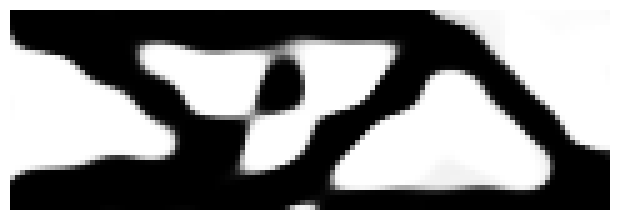

In [4]:
fig1, ax1 = plt.subplots(figsize=(6, 2))
ax1.imshow(-tt, cmap='gray', aspect='auto')
ax1.axis('off')
fig1.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig1.savefig('./22_120_noreg.pdf', bbox_inches='tight', pad_inches=0)

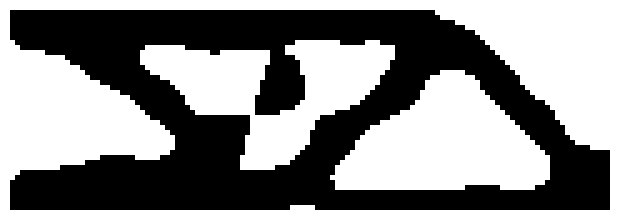

In [5]:
fig1, ax1 = plt.subplots(figsize=(6, 2))
ax1.imshow(1-tt_clean, cmap='gray', aspect='auto')
ax1.axis('off')
fig1.subplots_adjust(left=0, right=1, top=1, bottom=0)
fig1.savefig('./22_1200_noreg_clean.pdf', bbox_inches='tight', pad_inches=0)